In [1]:
import cv2
import numpy as np
import os
import glob
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pathlib import Path


In [8]:
cwd = Path.cwd()
ROOT_DIR = cwd.parent if cwd.name == "src" else cwd

DATA_DIR = ROOT_DIR / "data" / "processed" / "mask"
MODEL_DIR = ROOT_DIR / "models"
MODEL_NAME = "knn_baseline_model.pkl"

print(f"[*] ROOT  : {ROOT_DIR}")
print(f"[*] DATA  : {DATA_DIR}")
print(f"[*] MODELS: {MODEL_DIR}")

[*] ROOT  : c:\Users\ADMIN\Desktop\hung\cv\hung\hung1
[*] DATA  : c:\Users\ADMIN\Desktop\hung\cv\hung\hung1\data\processed\mask
[*] MODELS: c:\Users\ADMIN\Desktop\hung\cv\hung\hung1\models


In [3]:
def extract_hu_moments(img):
    """Trích xuất 7 giá trị Hu Moments từ ảnh mask."""
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
        
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return np.zeros(7)
        
    c = max(contours, key=cv2.contourArea)
    moments = cv2.moments(c)
    hu_moments = cv2.HuMoments(moments).flatten()
    
    for i in range(0, 7):
        if hu_moments[i] != 0:
            hu_moments[i] = -1 * np.copysign(1.0, hu_moments[i]) * np.log10(abs(hu_moments[i]))
            
    return hu_moments

In [4]:
def load_data(data_dir):
    print(f"[*] Đang đọc dữ liệu từ: {data_dir}")
    
    if not os.path.exists(data_dir):
        print(f"[!] LỖI: Không tìm thấy thư mục {data_dir}")
        return np.array([]), np.array([])

    class_mapping = {'fist': 0, 'two': 1, 'palm': 2}
    X, y = [], []
    total_images = 0
    
    for cls_name, cls_label in class_mapping.items():
        cls_dir = os.path.join(data_dir, cls_name)
        if not os.path.exists(cls_dir):
            print(f"  [Cảnh báo] Không tìm thấy thư mục class: {cls_dir}")
            continue
            
        file_patterns = [os.path.join(cls_dir, "*.jpg"), 
                         os.path.join(cls_dir, "*.png"),
                         os.path.join(cls_dir, "*.jpeg")]
        files = []
        for pattern in file_patterns:
            files.extend(glob.glob(pattern))
            
        print(f"  -> Class '{cls_name}' (label {cls_label}): {len(files)} ảnh.")
        
        for file in files:
            img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                features = extract_hu_moments(img)
                X.append(features)
                y.append(cls_label)
                total_images += 1
                
    print(f"[*] Tổng số ảnh đã load: {total_images}\n")
    return np.array(X), np.array(y)

[*] Đang đọc dữ liệu từ: c:\Users\ADMIN\Desktop\hung\cv\hung\hung1\data\processed\mask
  -> Class 'fist' (label 0): 750 ảnh.
  -> Class 'two' (label 1): 750 ảnh.
  -> Class 'palm' (label 2): 750 ảnh.
[*] Tổng số ảnh đã load: 2250


[*] Đang chạy GridSearchCV tìm tham số tối ưu...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

      KẾT QUẢ TUNING (GRID SEARCH)
[*] Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
[*] Best CV Score  : 96.67%

   ĐÁNH GIÁ TRÊN TẬP TEST (UNSEEN DATA)
Accuracy: 97.56%

Classification Report:
               precision    recall  f1-score   support

    fist (0)       0.97      0.98      0.98       150
     two (1)       0.98      0.98      0.98       150
    palm (2)       0.97      0.97      0.97       150

    accuracy                           0.98       450
   macro avg       0.98      0.98      0.98       450
weighted avg       0.98      0.98      0.98       450



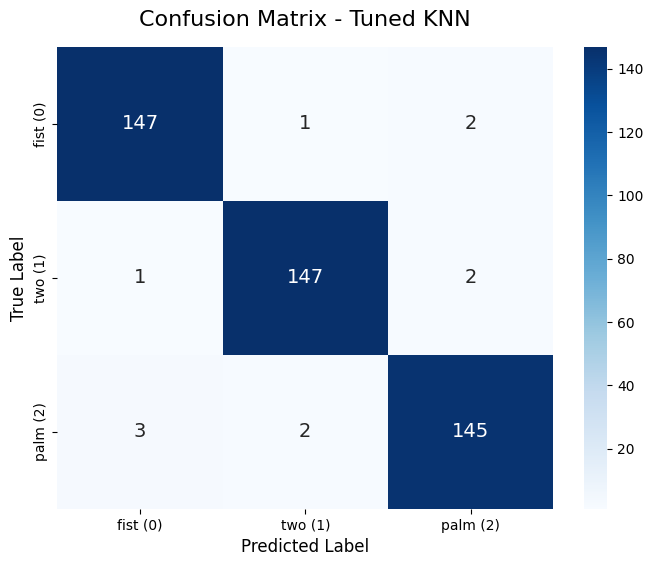


[*] Đã lưu BỘ MODEL TỐI ƯU thành công tại:
    c:\Users\ADMIN\Desktop\hung\cv\hung\hung1\models\knn_baseline_model.pkl


In [9]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
X, y = load_data(DATA_DIR)

if len(X) > 0:
    # 2. Chia tập Train/Test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # 3. Tạo Pipeline (Scaler + KNN)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier()) # Bỏ n_neighbors ở đây đi để GridSearchCV tự tìm
    ])
    
    # 4. Cấu hình Hyperparameter Tuning
    param_grid = {
        'knn__n_neighbors': [1, 3, 5, 7, 9],
        'knn__weights': ['uniform', 'distance'],
        'knn__metric': ['euclidean', 'manhattan']
    }
    
    # Cấu hình Stratified K-Fold (chia 5 fold, có xáo trộn data)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
        estimator=pipeline, 
        param_grid=param_grid, 
        cv=cv_strategy, 
        scoring='accuracy', 
        n_jobs=-1, # Dùng toàn bộ nhân CPU để chạy cho lẹ
        verbose=1  # In ra quá trình chạy
    )
    
    print("\n[*] Đang chạy GridSearchCV tìm tham số tối ưu...")
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    
    print("\n" + "="*40)
    print("      KẾT QUẢ TUNING (GRID SEARCH)")
    print("="*40)
    print(f"[*] Best Parameters: {grid_search.best_params_}")
    print(f"[*] Best CV Score  : {grid_search.best_score_ * 100:.2f}%")
    
    y_pred = best_model.predict(X_test)
    
    print("\n" + "="*40)
    print("   ĐÁNH GIÁ TRÊN TẬP TEST (UNSEEN DATA)")
    print("="*40)
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['fist (0)', 'two (1)', 'palm (2)']))
    
    # --- VẼ CONFUSION MATRIX ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    classes_names = ['fist (0)', 'two (1)', 'palm (2)']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes_names, yticklabels=classes_names,
                annot_kws={"size": 14})
    
    plt.title('Confusion Matrix - Tuned KNN', fontsize=16, pad=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    cm_image_path = ROOT_DIR / "confusion_matrix_tuned.png"
    plt.savefig(cm_image_path, bbox_inches='tight', dpi=300)
    plt.show()
    
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    model_path = MODEL_DIR / MODEL_NAME
    joblib.dump(best_model, model_path) # Lưu best_model (đã gộp cả pipeline)
    print(f"\n[*] Đã lưu BỘ MODEL TỐI ƯU thành công tại:\n    {model_path}")

else:
    print("[!] Dừng quá trình train vì không có dữ liệu.")

In [10]:
import random

def predict(img):
    model_path = os.path.join(MODEL_DIR, MODEL_NAME)
    model = joblib.load(model_path)
    
    features = extract_hu_moments(img).reshape(1, -1)
    prediction = model.predict(features)[0]
    return prediction

# ==========================================
# TEST TỰ ĐỘNG (Bốc ngẫu nhiên 3 ảnh để thử)
# ==========================================
print("--- TEST THỬ HÀM PREDICT VỚI ẢNH NGẪU NHIÊN ---")
class_mapping_reverse = {0: 'fist', 1: 'two', 2: 'palm'}
classes = ['fist', 'two', 'palm']

for cls in classes:
    # Tìm tất cả ảnh trong class này
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
        
    images = glob.glob(os.path.join(cls_dir, "*.jpg")) + glob.glob(os.path.join(cls_dir, "*.png"))
    
    if len(images) > 0:
        # Bốc ngẫu nhiên 1 ảnh
        random_img_path = random.choice(images)
        img_name = os.path.basename(random_img_path)
        
        # Đọc ảnh và predict
        test_img = cv2.imread(random_img_path, cv2.IMREAD_GRAYSCALE)
        pred_label = predict(test_img)
        pred_class_name = class_mapping_reverse[pred_label]
        
        print(f"Ảnh gốc: [{cls}] ({img_name}) ---> Model dự đoán: [{pred_class_name}] (Label: {pred_label})")

--- TEST THỬ HÀM PREDICT VỚI ẢNH NGẪU NHIÊN ---
Ảnh gốc: [fist] (fist_vuong_00077.jpg) ---> Model dự đoán: [fist] (Label: 0)
Ảnh gốc: [two] (two_hung_00160.jpg) ---> Model dự đoán: [two] (Label: 1)
Ảnh gốc: [palm] (palm_hung_00171.jpg) ---> Model dự đoán: [palm] (Label: 2)
